# SVHN: CNN-3 vs CNN-5 in TensorFlow and PyTorch

**Author:** Lưu Anh Dũng (B23DCDK036) · E23CNPM02 · Intelligent System Development · Assignment 05

**SVHN** (Street View House Numbers) = 99,289 color photos of house-number digits cut from Google Street View,
32×32 pixels, 10 classes (digits 0–9). Source: Kaggle
[`sahityasetu/street-view-house-numbers-images`](https://www.kaggle.com/datasets/sahityasetu/street-view-house-numbers-images).

Unlike MNIST, the digit sits in a real photo: other digits at the sides, blur, shadows, any color and font.

This notebook trains 4 models on the same data:

| Run ID | Framework | Model |
|---|---|---|
| `SV-TF-CNN-3` | TensorFlow/Keras | 3 convolutional layers |
| `SV-TF-CNN-5` | TensorFlow/Keras | 5 convolutional layers |
| `SV-PT-CNN-3` | PyTorch | 3 convolutional layers |
| `SV-PT-CNN-5` | PyTorch | 5 convolutional layers |

Sections 1–5 explain the method. Results are discussed in sections 6–7.

## 1. Setup

- **Seed = 42** for Python, NumPy, TensorFlow and PyTorch. Initial weights, batch order and dropout are random;
  fixing the seed makes a rerun give the same numbers.
- **Device.** PyTorch: `cuda` (NVIDIA) → `mps` (Apple) → `cpu`. TensorFlow uses an NVIDIA GPU on Linux/WSL2 or the Apple GPU
  automatically, otherwise the CPU (native Windows). TensorFlow is set to take GPU memory only as needed, so
  PyTorch can share the same GPU in this notebook.
- `A5_SMOKE=1` runs a quick test (2,000 training images, 2 epochs).

In [1]:
import copy
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEED = 42
warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
import keras
from keras import layers

keras.utils.set_random_seed(SEED)

import torch
import torch.nn as nn

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")

print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))
print("PyTorch", torch.__version__, "| device:", DEVICE)

TensorFlow 2.22.0-rc0 | GPUs: []
PyTorch 2.14.0+cpu | device: cpu


**Helper functions** (no model code): project paths, the saved split, test metrics, result files and plots.
Settings shared by both frameworks: batch 256, max 20 epochs, early-stopping patience 3, learning rate 0.001.

In [2]:
import json
import os
import random
from pathlib import Path

from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split

SMOKE = os.environ.get("A5_SMOKE") == "1"          # quick test: small subsample, 2 epochs


def find_root():
    """assignment_05/ = first folder above the working directory that has dataset/ and notebook/."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "dataset").is_dir() and (p / "notebook").is_dir():
            return p
    return here.parent


ROOT = find_root()
DATA_DIR = Path(os.environ.get("A5_DATA_DIR", ROOT / "dataset"))
RESULTS_DIR = ROOT / "notebook" / "results" / ("smoke" if SMOKE else "")
MODELS_DIR = ROOT / "notebook" / "models" / ("smoke" if SMOKE else "")
FIG_DIR = ROOT / "report" / "images" / ("smoke" if SMOKE else "")
for d in (RESULTS_DIR, MODELS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 256
EPOCHS = 2 if SMOKE else 20
PATIENCE = 3
LEARNING_RATE = 1e-3
SMOKE_SIZE = {"train": 2000, "validation": 500, "test": 500}

random.seed(SEED)
np.random.seed(SEED)
print("project folder:", ROOT, "| smoke run:", SMOKE, "| epochs:", EPOCHS, "| batch size:", BATCH_SIZE)


def find_file(code, name):
    """Find `name` anywhere under dataset/<code>/ (unzipping may add a subfolder)."""
    base = DATA_DIR / code.lower()
    hits = sorted(base.rglob(name))
    if not hits:
        raise FileNotFoundError(f"{name} not found under {base}; see dataset/README.md")
    return hits[0]


def make_or_load_splits(code, y, n_sample=None):
    """Stratified 70/15/15 split of row indices, saved once to dataset/<code>/splits.npz."""
    path = DATA_DIR / code.lower() / "splits.npz"
    n_sample = min(n_sample or len(y), len(y))
    splits = None
    if path.exists():
        saved = np.load(path)
        splits = {k: saved[k] for k in ("train", "validation", "test")}
        if sum(len(v) for v in splits.values()) != n_sample:
            splits = None
    if splits is None:
        idx = np.arange(len(y))
        if n_sample < len(y):
            idx, _ = train_test_split(idx, train_size=n_sample, stratify=y, random_state=SEED)
        train, rest = train_test_split(idx, train_size=0.70, stratify=y[idx], random_state=SEED)
        val, test = train_test_split(rest, test_size=0.50, stratify=y[rest], random_state=SEED)
        splits = {"train": np.sort(train), "validation": np.sort(val), "test": np.sort(test)}
        np.savez(path, **splits)
    if SMOKE:
        rng = np.random.default_rng(SEED)
        splits = {k: np.sort(rng.choice(v, min(SMOKE_SIZE[k], len(v)), replace=False)) for k, v in splits.items()}
    return splits


def classification_metrics(y_true, y_pred, y_score=None, binary=False):
    """Accuracy + macro precision/recall/F1; for binary tasks also positive-class F1, ROC-AUC, AP."""
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    if binary:
        m["f1_positive"] = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        m["roc_auc"] = roc_auc_score(y_true, y_score)
        m["average_precision"] = average_precision_score(y_true, y_score)
    return {k: float(v) for k, v in m.items()}


class Stopwatch:
    def __enter__(self):
        self._start = time.perf_counter()
        return self

    def __exit__(self, *exc):
        self.seconds = time.perf_counter() - self._start


def save_result(record):
    (RESULTS_DIR / f"{record['run_id']}.json").write_text(json.dumps(record, indent=2), encoding="utf-8")


def load_results(run_ids):
    paths = [RESULTS_DIR / f"{rid}.json" for rid in run_ids]
    return [json.loads(p.read_text(encoding="utf-8")) for p in paths if p.exists()]


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


def plot_history(history, run_id):
    """Figure with 2 plots: loss and accuracy per epoch, train vs validation."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    epochs = np.arange(1, len(history["loss"]) + 1)
    for ax, key, title in [(axes[0], "loss", "Loss"), (axes[1], "accuracy", "Accuracy")]:
        ax.plot(epochs, history[key], marker="o", label="train")
        ax.plot(epochs, history[f"val_{key}"], marker="o", label="validation")
        ax.set_title(f"{run_id}: {title}"); ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout(); savefig(fig, f"{run_id}_curves"); plt.show()


def plot_confusion(y_true, y_pred, labels, run_id):
    """Row-normalized confusion matrix: row = true class, column = predicted class."""
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    shown = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    many = len(labels) > 12
    size = max(4.5, 0.28 * len(labels))
    fig, ax = plt.subplots(figsize=(size + 1, size))
    im = ax.imshow(shown, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90 if many else 0, fontsize=7 if many else 9)
    ax.set_yticklabels(labels, fontsize=7 if many else 9)
    if not many:
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, f"{shown[i, j]:.2f}", ha="center", va="center", fontsize=8,
                        color="white" if shown[i, j] > 0.5 else "black")
    ax.set_xlabel("predicted class"); ax.set_ylabel("true class")
    ax.set_title(f"{run_id}: confusion matrix (row-normalized)")
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout(); savefig(fig, f"{run_id}_confusion"); plt.show()
    return cm


def results_table(records):
    rows = []
    for r in records:
        row = {"run_id": r["run_id"], "framework": r["framework"], "model": r["model"], "params": r["params"],
               "epochs": r["epochs_run"], "time_per_epoch_s": r["time_per_epoch_s"],
               "train_time_s": r["train_time_s"], "inference_ms_per_1k": r["inference_ms_per_1k"]}
        row.update(r["test_metrics"])
        rows.append(row)
    return pd.DataFrame(rows).set_index("run_id")

project folder: F:\Code\intelligent_system_assignments\assignment_05 | smoke run: False | epochs: 20 | batch size: 256


Every model has a **run ID** `<dataset>-<framework>-<model>`. The same ID names its result file and its figures.

In [3]:
DATASET = "SV"
MODELS = ["CNN-3", "CNN-5"]
FRAMEWORKS = ["TF", "PT"]
RUN_IDS = [f"{DATASET}-{fw}-{m}" for fw in FRAMEWORKS for m in MODELS]
RUN_IDS

['SV-TF-CNN-3', 'SV-TF-CNN-5', 'SV-PT-CNN-3', 'SV-PT-CNN-5']

## 2. Data

### 2.1 Load

SVHN comes as two MATLAB files. `scipy.io.loadmat` reads each one into NumPy arrays:

| Array | Shape in file | Fix |
|---|---|---|
| `X` | `(32, 32, 3, N)`: height, width, color, **sample last** | move samples first → `(N, 32, 32, 3)` |
| `y` | `(N, 1)`, digit 0 stored as **10** | `10 → 0`, so label = digit |

In [4]:
from scipy.io import loadmat

parts = []
for name in ["train_32x32.mat", "test_32x32.mat"]:
    mat = loadmat(find_file(DATASET, name))
    parts.append((np.transpose(mat["X"], (3, 0, 1, 2)), mat["y"].ravel()))

X_raw = np.concatenate([x for x, _ in parts]).astype(np.uint8)    # (N, 32, 32, 3), values 0..255
y_raw = np.concatenate([y for _, y in parts]).astype(np.int64)
y_raw[y_raw == 10] = 0                                            # digit 0 was stored as 10

CLASS_NAMES = [str(d) for d in range(10)]
CLASS_LABELS = CLASS_NAMES
print("X_raw:", X_raw.shape, "| y_raw:", y_raw.shape, "| labels:", np.unique(y_raw))

X_raw: (99289, 32, 32, 3) | y_raw: (99289,) | labels: [0 1 2 3 4 5 6 7 8 9]


### 2.2 Split 70 / 15 / 15

Both files are pooled (99,289 images) and split again, **stratified**: every digit keeps its share in each set.
Example: if 19% of all images are "1", then about 19% of train, validation and test are "1".

| Set | Share | Used for |
|---|---|---|
| train | 70% | updating the weights |
| validation | 15% | early stopping (when to stop training) |
| test | 15% | final score, used once |

The row indices go into `dataset/sv/splits.npz`, so TensorFlow and PyTorch use exactly the same images.

In [5]:
splits = make_or_load_splits(DATASET, y_raw)
X_train, y_train = X_raw[splits["train"]], y_raw[splits["train"]]
X_val, y_val = X_raw[splits["validation"]], y_raw[splits["validation"]]
X_test, y_test = X_raw[splits["test"]], y_raw[splits["test"]]
N_CLASSES = len(CLASS_NAMES)

sizes = pd.Series({"train": len(y_train), "validation": len(y_val), "test": len(y_test)})
pd.DataFrame({"samples": sizes, "share": (sizes / sizes.sum()).round(3)})

,samples,share
train,69502,0.70
validation,14893,0.15
test,14894,0.15


### 2.3 Scale and layout

- **Scale:** `x / 255`, so `0 → 0.0`, `128 → 0.50`, `255 → 1.0`. Small inputs keep the first layer's sums small and
  training stable. Images stay `uint8` in memory (1 byte per value) and are divided **per batch**.
- **Layout:** same numbers, different axis order.
  - Keras: `(N, H, W, C) = (N, 32, 32, 3)`
  - PyTorch: `(N, C, H, W) = (N, 3, 32, 32)`

In [6]:
def to_channels_first(x):
    """(N, H, W, C) -> (N, C, H, W) for PyTorch; still uint8."""
    return np.ascontiguousarray(np.transpose(x, (0, 3, 1, 2)))

X_train_pt, X_val_pt, X_test_pt = (to_channels_first(x) for x in (X_train, X_val, X_test))
INPUT_SHAPE_TF = X_train.shape[1:]      # (H, W, C)
INPUT_CHANNELS = X_train.shape[-1]      # C
print("TF layout:", X_train.shape, "| PT layout:", X_train_pt.shape, "| dtype:", X_train.dtype)

TF layout: (69502, 32, 32, 3) | PT layout: (69502, 3, 32, 32) | dtype: uint8


## 3. Look at the data

**Images per digit.** House numbers contain more small digits (1, 2) than large ones (9, 0), so the classes are
not equal. Accuracy can hide a weak digit, so **macro F1** (every digit weighted equally) is reported too.

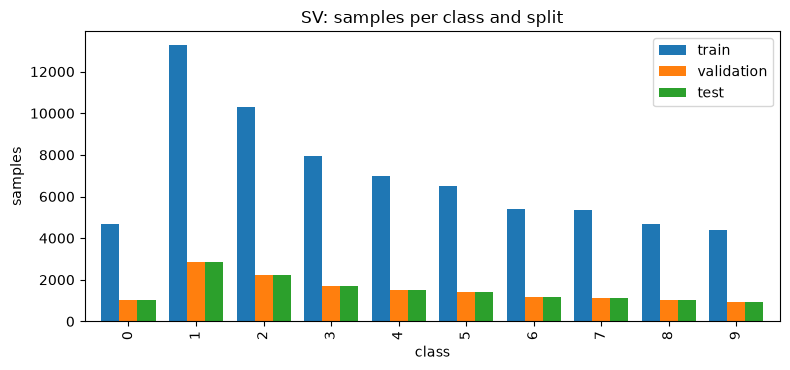

smallest class: 9 (4378) | largest class: 1 (13272) | largest / smallest = 3.0


In [7]:
counts = pd.DataFrame({name: np.bincount(y_raw[idx], minlength=N_CLASSES) for name, idx in splits.items()},
                      index=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(max(8, N_CLASSES * 0.3), 3.8))
counts.plot.bar(ax=ax, width=0.8)
ax.set_xlabel("class"); ax.set_ylabel("samples"); ax.set_title(f"{DATASET}: samples per class and split")
fig.tight_layout(); savefig(fig, f"{DATASET}_class_distribution"); plt.show()

train_counts = counts["train"]
print(f"smallest class: {train_counts.idxmin()} ({train_counts.min()}) | largest class: {train_counts.idxmax()} "
      f"({train_counts.max()}) | largest / smallest = {train_counts.max() / train_counts.min():.1f}")

**Samples.** 8 training images per digit. The label is the **centre** digit; the digits beside it are noise the model must learn to ignore.

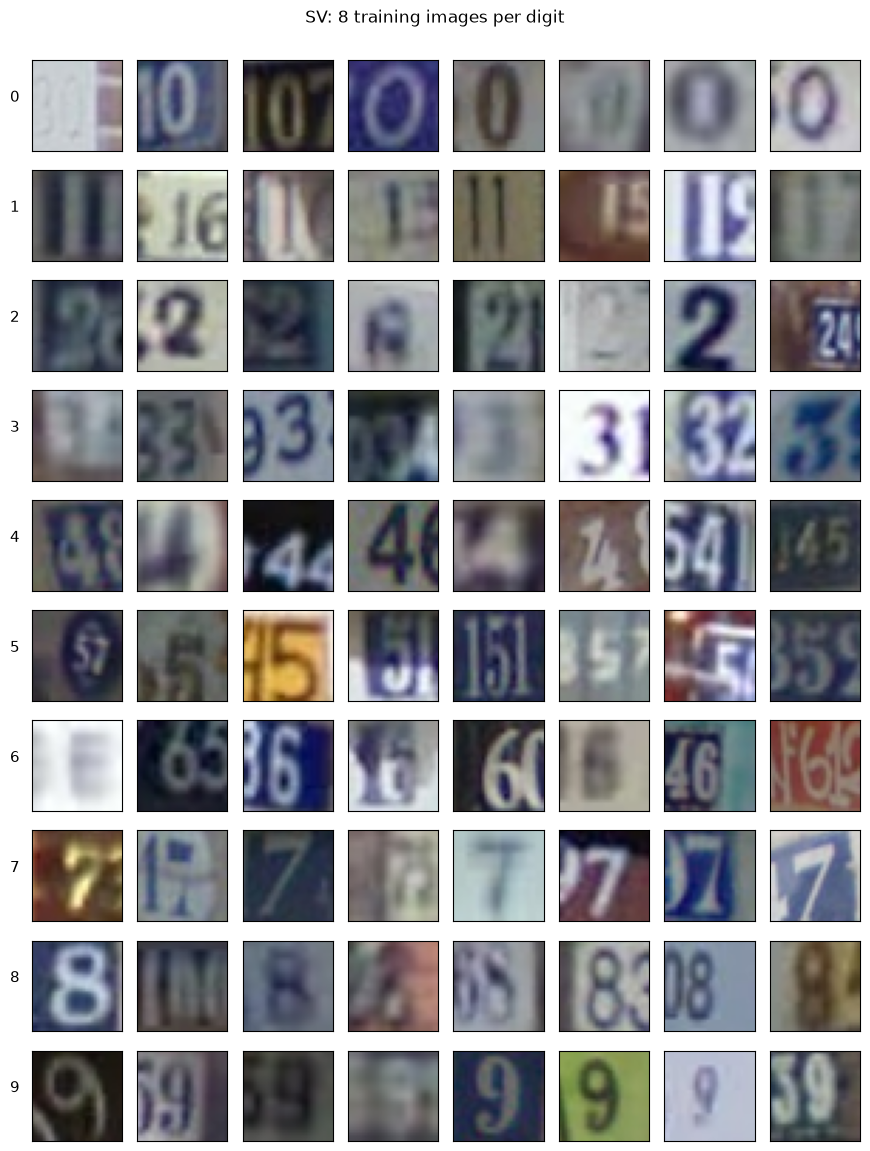

In [8]:
per_class = 8
fig, axes = plt.subplots(N_CLASSES, per_class, figsize=(per_class * 1.1, N_CLASSES * 1.15))
rng = np.random.default_rng(SEED)
for c in range(N_CLASSES):
    for j, i in enumerate(rng.choice(np.where(y_train == c)[0], per_class, replace=False)):
        ax = axes[c, j]
        ax.imshow(X_train[i]); ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(CLASS_NAMES[c], rotation=0, labelpad=12, fontsize=11)
fig.suptitle(f"{DATASET}: 8 training images per digit", y=1.0)
fig.tight_layout(); savefig(fig, f"{DATASET}_samples"); plt.show()

**Pixel values.** Mean and spread per color channel, and the brightness of each image (its mean pixel value).

,mean,std
red,0.440,0.204
green,0.444,0.208
blue,0.471,0.206


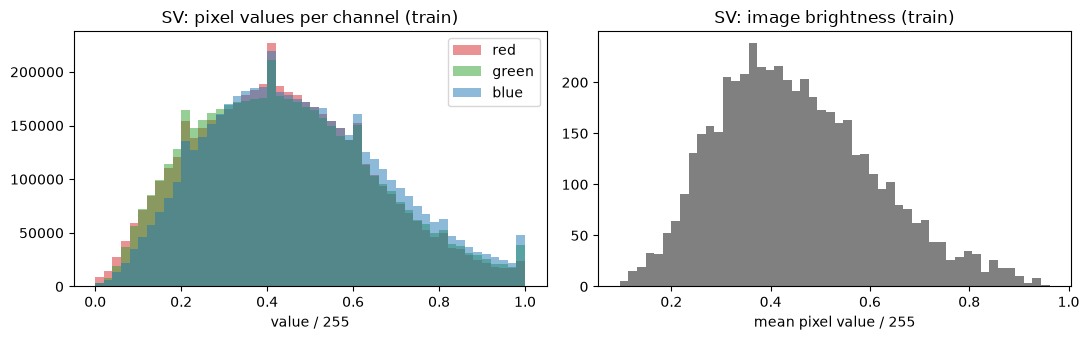

In [9]:
rng = np.random.default_rng(SEED)
sub = X_train[rng.choice(len(X_train), min(5000, len(X_train)), replace=False)].astype(np.float32) / 255.0
channel_names = ["red", "green", "blue"]
display(pd.DataFrame({"mean": sub.mean(axis=(0, 1, 2)), "std": sub.std(axis=(0, 1, 2))}, index=channel_names).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ch, color in enumerate(["tab:red", "tab:green", "tab:blue"]):
    axes[0].hist(sub[..., ch].ravel(), bins=50, alpha=0.5, color=color, label=channel_names[ch])
axes[0].set_title(f"{DATASET}: pixel values per channel (train)"); axes[0].set_xlabel("value / 255"); axes[0].legend()
axes[1].hist(sub.mean(axis=(1, 2, 3)), bins=50, color="gray")
axes[1].set_title(f"{DATASET}: image brightness (train)"); axes[1].set_xlabel("mean pixel value / 255")
fig.tight_layout(); savefig(fig, f"{DATASET}_pixel_stats"); plt.show()

## 4. TensorFlow / Keras

### 4.1 Input pipeline

`tf.data`: shuffle (train only) → batch of 256 → `/255` → prefetch.
One training batch is a tensor of shape `(256, 32, 32, 3)`.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE


def scale(x, y):
    return tf.cast(x, tf.float32) / 255.0, y


def make_tf_dataset(x, y, training):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(len(x), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).map(scale, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


train_ds = make_tf_dataset(X_train, y_train, training=True)
val_ds = make_tf_dataset(X_val, y_val, training=False)
test_ds = make_tf_dataset(X_test, y_test, training=False)
train_ds.element_spec

(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int64, name=None))

### 4.2 One conv block, by hand

A conv block is **Conv → BatchNorm → ReLU → MaxPool**. Here is each step on a 5×5 gray patch that contains a
vertical stroke, like part of a digit "1":

```
patch            filter (vertical edge)
0 0 1 1 0        -1 0 1
0 0 1 1 0        -1 0 1
... (5 rows)     -1 0 1
```

- **Convolution:** slide the 3×3 filter over the patch; at each position `out = Σ (window × filter) + bias`.
  - window `[0 0 1]` per row → `(−1·0 + 0·0 + 1·1) × 3 rows = 3` → left edge of the stroke: strong response
  - window `[0 1 1]` → `(0 + 0 + 1) × 3 = 3`
  - window `[1 1 0]` → `(−1 + 0 + 0) × 3 = −3` → right edge: opposite sign
- **ReLU** `= max(0, x)`: `3 → 3`, `−3 → 0`. Only positive responses pass.
- **MaxPool 2×2:** keep the largest of each 2×2 block, e.g. `[[3, 3], [3, 0]] → 3`. Height and width halve.
- **BatchNorm:** per channel, over the batch: `x̂ = (x − μ) / √(σ² + ε)`, then `out = γ·x̂ + β` (γ, β learned).
  Example `[1, 3, 5]`: μ = 3, σ = 1.63 → `[−1.22, 0, 1.22]`.

A real layer does the same with **learned** filters of size 3×3×3 (3 color channels), 32 or more of them.
The cell checks the hand result against TensorFlow's `tf.nn.conv2d`.

In [11]:
patch = np.array([[0, 0, 1, 1, 0]] * 5, dtype=np.float32)          # vertical stroke, 5x5
kernel = np.array([[-1, 0, 1]] * 3, dtype=np.float32)              # vertical-edge filter, 3x3

conv = np.array([[np.sum(patch[i:i + 3, j:j + 3] * kernel) for j in range(3)] for i in range(3)])
relu = np.maximum(0, conv)
pooled = relu[:2, :2].max()
tf_conv = tf.nn.conv2d(patch[None, :, :, None], kernel[:, :, None, None], strides=1, padding="VALID")[0, :, :, 0]

print("convolution (by hand):\n", conv)
print("same as tf.nn.conv2d:", np.allclose(conv, tf_conv.numpy()))
print("ReLU:\n", relu)
print("MaxPool of the top-left 2x2 block:", pooled)

values = np.array([1.0, 3.0, 5.0])
print("BatchNorm of [1, 3, 5] (gamma=1, beta=0):", ((values - values.mean()) / np.sqrt(values.var() + 1e-5)).round(2))

convolution (by hand):
 [[ 3.  3. -3.]
 [ 3.  3. -3.]
 [ 3.  3. -3.]]
same as tf.nn.conv2d: True
ReLU:
 [[3. 3. 0.]
 [3. 3. 0.]
 [3. 3. 0.]]
MaxPool of the top-left 2x2 block: 3.0
BatchNorm of [1, 3, 5] (gamma=1, beta=0): [-1.22  0.    1.22]


### 4.3 The CNN-3 model

This cell builds CNN-3: three conv blocks (Conv → BatchNorm → ReLU → MaxPool), then a small classifier head.

| Layer | Computation | Shape (one image) |
|---|---|---|
| Input | pixels / 255 | 32×32×3 |
| Conv 3×3, 32 filters | each position: Σ(3×3×3 window × weights) + bias | 32×32×32 |
| BatchNorm | (x − μ)/σ · γ + β, e.g. [1, 3, 5] → [−1.22, 0, 1.22] | 32×32×32 |
| ReLU | max(0, x): −1.3 → 0, 0.8 → 0.8 | 32×32×32 |
| MaxPool 2×2 | largest of 4: [[0.1, 0.9], [0.4, 0.2]] → 0.9 | 16×16×32 |
| Blocks 2, 3 | same, with 64 then 128 filters | 8×8×64 → 4×4×128 |
| GAP | mean of each 4×4 map → one number | 128 |
| Dropout 0.3 | in training, 30% of values set to 0 | 128 |
| Dense 256 → Dense 10 | 10 scores (logits), one per digit | 10 |

- `padding="same"` adds a zero border, so 32×32 stays 32×32 after each Conv.
- Conv parameters = (3·3·C_in + 1)·F, e.g. first layer (3·3·3 + 1)·32 = 896.
- **CNN-5** is the same, but blocks 1 and 2 have two Convs before the pool (32, 32 and 64, 64).
  Same output shapes; one final unit sees 28×28 input pixels instead of 22×22.

The next cell passes one real image through every layer and prints each output shape.

In [12]:
ARCH = {  # (filters, max-pool after this conv?)
    "CNN-3": [(32, True), (64, True), (128, True)],
    "CNN-5": [(32, False), (32, True), (64, False), (64, True), (128, True)],
}
HEAD_UNITS = 256
DROPOUT = 0.3


def conv_block_tf(x, filters, pool):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)(x)
    x = layers.ReLU()(x)
    if pool:
        x = layers.MaxPooling2D(2)(x)
    return x


def build_tf(model_name, input_shape, n_classes):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for filters, pool in ARCH[model_name]:
        x = conv_block_tf(x, filters, pool)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(HEAD_UNITS, activation="relu")(x)
    outputs = layers.Dense(n_classes)(x)            # logits
    return keras.Model(inputs, outputs, name=f"{DATASET}_TF_{model_name.replace('-', '')}")

In [13]:
image = X_train[:1].astype(np.float32) / 255.0          # one training image, batch of 1
for m in MODELS:
    model = build_tf(m, INPUT_SHAPE_TF, N_CLASSES)
    x, rows = image, []
    for layer in model.layers[1:]:
        x = layer(x, training=False)
        rows.append((layer.__class__.__name__, tuple(x.shape[1:]), layer.count_params()))
    print(f"{m}: one image through every layer")
    display(pd.DataFrame(rows, columns=["layer", "output shape", "params"]).T)

CNN-3: one image through every layer


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
layer,Conv2D,BatchNormalization,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,MaxPooling2D,GlobalAveragePooling2D,Dropout,Dense,Dense
output shape,"(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(16, 16, 32)","(16, 16, 64)","(16, 16, 64)","(16, 16, 64)","(8, 8, 64)","(8, 8, 128)","(8, 8, 128)","(8, 8, 128)","(4, 4, 128)","(128,)","(128,)","(256,)","(10,)"
params,896,128,0,0,18496,256,0,0,73856,512,0,0,0,0,33024,2570


CNN-5: one image through every layer

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
layer,Conv2D,BatchNormalization,ReLU,Conv2D,BatchNormalization,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,...,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,MaxPooling2D,GlobalAveragePooling2D,Dropout,Dense,Dense
output shape,"(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(16, 16, 32)","(16, 16, 64)","(16, 16, 64)","(16, 16, 64)",...,"(16, 16, 64)","(8, 8, 64)","(8, 8, 128)","(8, 8, 128)","(8, 8, 128)","(4, 4, 128)","(128,)","(128,)","(256,)","(10,)"
params,896,128,0,9248,128,0,0,18496,256,0,...,0,0,73856,512,0,0,0,0,33024,2570


### 4.4 Parameters

| Layer | Formula | Example (first conv) |
|---|---|---|
| Conv | `(K·K·C_in + 1)·F` | `(3·3·3 + 1)·32 = 896` |
| BatchNorm | `2·F` (γ, β) | `2·32 = 64` |
| Dense | `(inputs + 1)·units` | `(256 + 1)·10 = 2,570` (output) |
| Pool, ReLU, Dropout | 0 | |

Only **trainable** parameters are counted: BatchNorm's running mean/variance are not learned by gradients.
The PyTorch models must reach the same totals (section 5).

In [14]:
def expected_params(model_name, in_channels, n_classes):
    rows, c = [], in_channels
    for i, (f, _) in enumerate(ARCH[model_name], start=1):
        rows.append((f"conv{i}", f"(3·3·{c} + 1)·{f}", (9 * c + 1) * f))
        rows.append((f"bn{i}", f"2·{f}", 2 * f))
        c = f
    rows.append(("dense", f"({c} + 1)·{HEAD_UNITS}", (c + 1) * HEAD_UNITS))
    rows.append(("output", f"({HEAD_UNITS} + 1)·{n_classes}", (HEAD_UNITS + 1) * n_classes))
    return pd.DataFrame(rows, columns=["layer", "formula", "params"])


def trainable_params_tf(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))


for m in MODELS:
    table = expected_params(m, INPUT_CHANNELS, N_CLASSES)
    print(f"{m}: {table.params.sum():,} trainable parameters")
    display(table.set_index("layer").T)

CNN-3: 129,290 trainable parameters


layer,conv1,bn1,conv2,bn2,conv3,bn3,dense,output
formula,(3·3·3 + 1)·32,2·32,(3·3·32 + 1)·64,2·64,(3·3·64 + 1)·128,2·128,(128 + 1)·256,(256 + 1)·10
params,896,64,18496,128,73856,256,33024,2570


CNN-5: 175,658 trainable parameters


layer,conv1,bn1,conv2,bn2,conv3,bn3,conv4,bn4,conv5,bn5,dense,output
formula,(3·3·3 + 1)·32,2·32,(3·3·32 + 1)·32,2·32,(3·3·32 + 1)·64,2·64,(3·3·64 + 1)·64,2·64,(3·3·64 + 1)·128,2·128,(128 + 1)·256,(256 + 1)·10
params,896,64,9248,64,18496,128,36928,128,73856,256,33024,2570


### 4.5 Loss and training

This cell compiles and trains the model with early stopping.

| Part | Computation | Example |
|---|---|---|
| Softmax | p_k = e^(z_k) / Σ e^(z_j) | logits "3" = 2, "8" = 1, rest 0 → p("3") = 0.41 |
| Cross-entropy | L = −ln p(true class) | true 3: −ln 0.41 = 0.90; true 8: −ln 0.15 = 1.90 |
| Start of training | all p = 1/10 | L = ln 10 = 2.30 |
| Adam | w ← w − 0.001 · m / (√v + ε) | each weight gets its own step size |
| Epoch | all training batches of 256 once | ≈ 272 updates |
| Early stopping | stop after 3 epochs with no lower validation loss | keep the best epoch's weights |

- `from_logits=True`: softmax is applied inside the loss (more stable).
- Time per epoch = median of epochs 2+ (epoch 1 also builds the graph).
- **Progress:** a bar inside each epoch (Keras bar / `tqdm` in PyTorch) shows the time left for that epoch. After each epoch:
  `time left ≈ median epoch time × epochs left`, e.g. 30 s × 17 = 8.5 min. It is an upper bound, since early stopping usually ends sooner.

In [15]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.perf_counter() - self._start)


def train_tf(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, epsilon=1e-7),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    timer = EpochTimer()
    stopper = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[stopper, timer], verbose=2)
    hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    return hist, timer.times, int(np.argmin(hist["val_loss"])) + 1

### 4.6 Test metrics

Prediction = digit with the highest probability. For each digit `c`:

| Metric | Formula | Example for digit 7 |
|---|---|---|
| precision | TP / (TP + FP) | 90 images predicted "7", 81 correct → 0.90 |
| recall | TP / (TP + FN) | 100 real 7s, 81 found → 0.81 |
| F1 | 2·P·R / (P + R) | 2·0.90·0.81 / 1.71 = 0.85 |

**Macro** = average over the 10 digits. **Accuracy** = correct / all test images.
The **confusion matrix** row `i`, column `j` = share of true digit `i` predicted as `j`.

In [16]:
def evaluate_tf(model):
    model.predict(test_ds.take(1), verbose=0)           # warm-up, not timed
    with Stopwatch() as t:
        logits = model.predict(test_ds, verbose=0)
    probs = tf.nn.softmax(logits).numpy()
    y_pred = probs.argmax(axis=1)
    return y_pred, probs, classification_metrics(y_test, y_pred), 1000 * t.seconds / len(y_test)


def make_record(run_id, framework, model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k):
    return {
        "run_id": run_id, "dataset": DATASET, "framework": framework, "model": model_name,
        "params": params, "epochs_run": len(epoch_times), "best_epoch": best_epoch,
        "train_time_s": float(sum(epoch_times)),
        # epoch 1 includes one-time setup (graph tracing, GPU kernel loading): excluded here
        "time_per_epoch_s": float(np.median(epoch_times[1:] if len(epoch_times) > 1 else epoch_times)),
        "inference_ms_per_1k": float(ms_per_1k), "test_metrics": metrics,
        "history": {k: hist[k] for k in ("loss", "val_loss", "accuracy", "val_accuracy")},
        "smoke": SMOKE,
    }


def run_tf(model_name):
    run_id = f"{DATASET}-TF-{model_name}"
    keras.utils.set_random_seed(SEED)                 # same initial weights on every rerun
    model = build_tf(model_name, INPUT_SHAPE_TF, N_CLASSES)
    params = trainable_params_tf(model)
    assert params == expected_params(model_name, INPUT_CHANNELS, N_CLASSES).params.sum()
    model.summary()
    hist, epoch_times, best_epoch = train_tf(model)
    y_pred, probs, metrics, ms_per_1k = evaluate_tf(model)
    record = make_record(run_id, "TF", model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k)
    save_result(record)
    model.save(MODELS_DIR / f"{run_id}.keras")
    print(pd.Series(metrics).round(4).to_string())
    plot_history(record["history"], run_id)
    plot_confusion(y_test, y_pred, CLASS_LABELS, run_id)
    return model, y_pred, record

### 4.7 `SV-TF-CNN-3`
Build → check parameters → train → test → save `results/SV-TF-CNN-3.json` → plot curves and confusion matrix.

Model: "SV_TF_CNN3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_8 (ReLU)                       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_9 (ReLU)                       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_10 (ReLU)                      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

...

Epoch 19/20


272/272 - 48s - 176ms/step - accuracy: 0.9161 - loss: 0.2776 - val_accuracy: 0.9073 - val_loss: 0.3157


Epoch 20/20


272/272 - 45s - 167ms/step - accuracy: 0.9208 - loss: 0.2634 - val_accuracy: 0.9063 - val_loss: 0.3112


accuracy           0.9117
precision_macro    0.9068
recall_macro       0.9104
f1_macro           0.9072


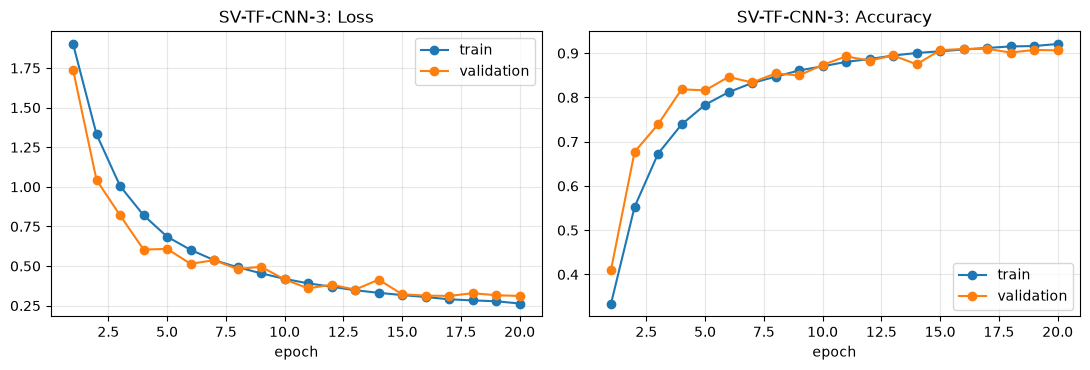

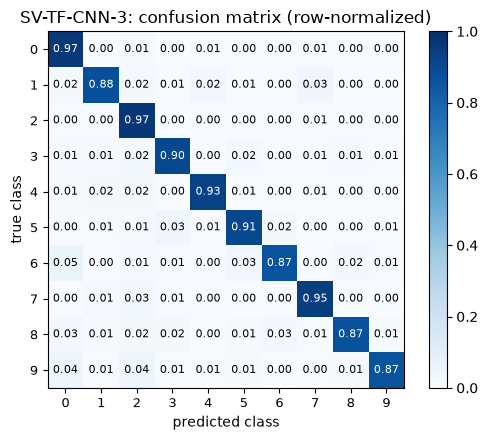

In [17]:
tf_models, tf_preds = {}, {}
tf_models["CNN-3"], tf_preds["CNN-3"], _ = run_tf("CNN-3")

### 4.8 `SV-TF-CNN-5`
Same steps, 5 convolutional layers.

Model: "SV_TF_CNN5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_11 (ReLU)                      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_12 (ReLU)                      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_13 (ReLU)                      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_14 (ReLU)                      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_15 (ReLU)                      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 4, 4, 128)           │              

 Total params: 176,298 (688.66 KB)

 Trainable params: 175,658 (686.16 KB)

 Non-trainable params: 640 (2.50 KB)

...

Epoch 9/20


272/272 - 85s - 311ms/step - accuracy: 0.9348 - loss: 0.2213 - val_accuracy: 0.9088 - val_loss: 0.3088


Epoch 10/20


272/272 - 85s - 313ms/step - accuracy: 0.9392 - loss: 0.2097 - val_accuracy: 0.9200 - val_loss: 0.2831


accuracy           0.9306
precision_macro    0.9286
recall_macro       0.9248
f1_macro           0.9265


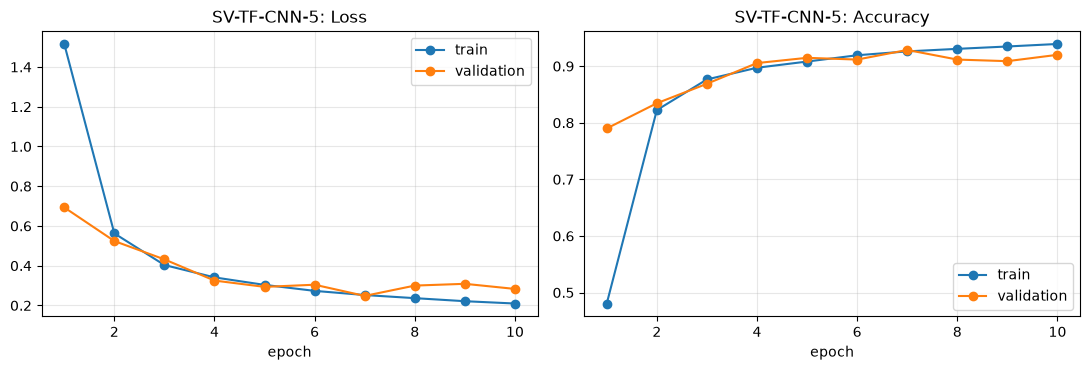

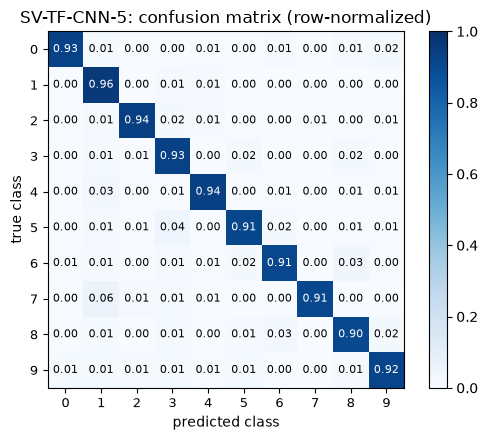

In [18]:
tf_models["CNN-5"], tf_preds["CNN-5"], _ = run_tf("CNN-5")

### 4.9 What the first layer learned

- **Filters:** the first Conv has 32 filters of 3×3×3. Each is drawn as a tiny 3×3 color image
  (scaled to 0–1). Edge filters look like a dark side and a bright side.
- **Feature maps:** the output of each filter after ReLU for one test image. Bright = strong response
  (e.g. along the digit's edges).

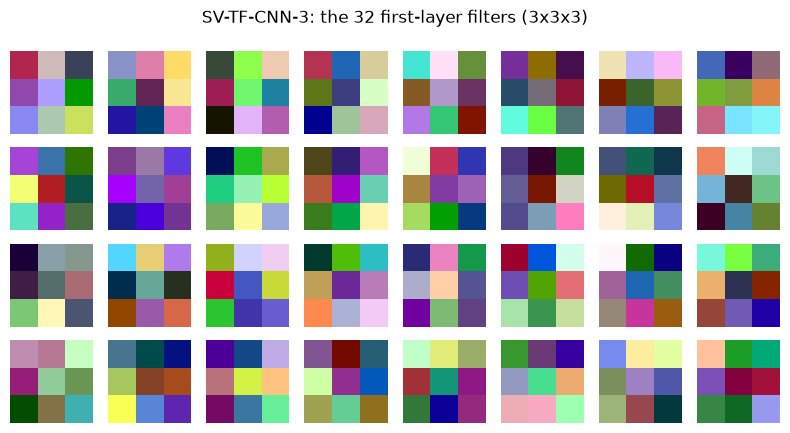

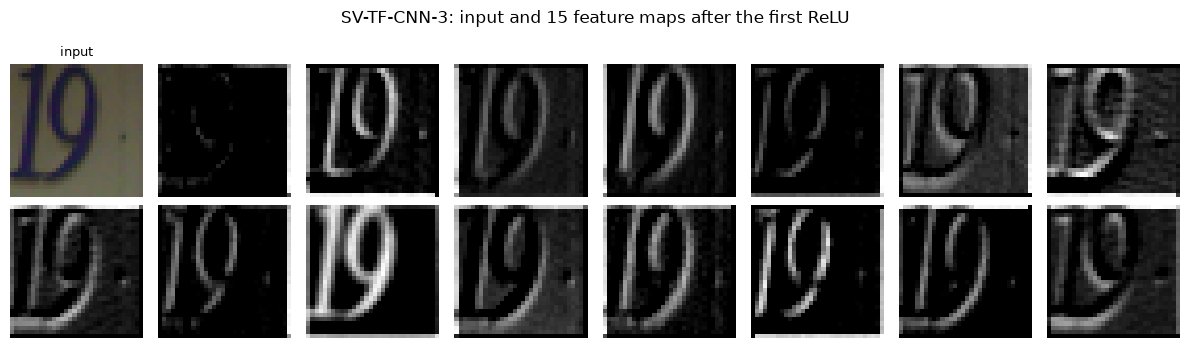

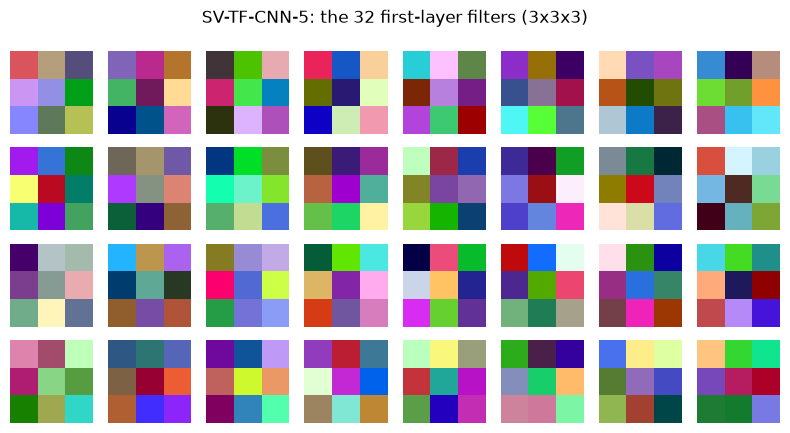

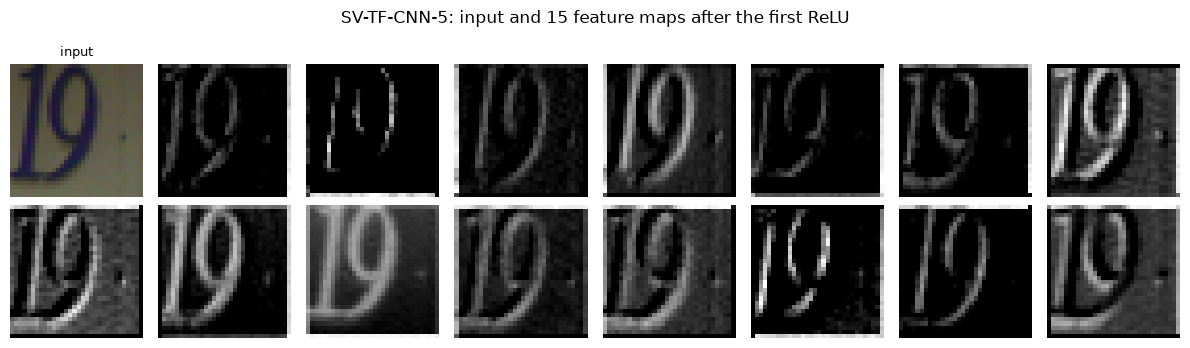

In [19]:
sample = X_test[:1].astype(np.float32) / 255.0          # one test image


def show_filters(filters, run_id):
    """filters: (F, K, K, C_in). Each filter is min-max scaled and drawn as a 3x3 color image."""
    fig, axes = plt.subplots(4, 8, figsize=(8, 4.4))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, f in zip(axes.ravel(), filters):
        ax.imshow((f - f.min()) / (f.max() - f.min() + 1e-8))
    fig.suptitle(f"{run_id}: the 32 first-layer filters (3x3x3)")
    fig.tight_layout(); savefig(fig, f"{run_id}_filters"); plt.show()


def show_feature_maps(maps, run_id):
    """maps: (F, H, W) after the first ReLU. First panel = the input image."""
    fig, axes = plt.subplots(2, 8, figsize=(12, 3.6))
    for ax in axes.ravel():
        ax.axis("off")
    axes[0, 0].imshow(sample[0]); axes[0, 0].set_title("input", fontsize=9)
    for ax, fm in zip(axes.ravel()[1:], maps):
        ax.imshow(fm, cmap="gray")
    fig.suptitle(f"{run_id}: input and 15 feature maps after the first ReLU")
    fig.tight_layout(); savefig(fig, f"{run_id}_feature_maps"); plt.show()


def tf_filters(m):
    conv = next(l for l in tf_models[m].layers if isinstance(l, layers.Conv2D))
    return np.transpose(conv.get_weights()[0], (3, 0, 1, 2))            # (K, K, C_in, F) -> (F, K, K, C_in)


def tf_maps(m):
    model = tf_models[m]
    relu = next(l for l in model.layers if isinstance(l, layers.ReLU))
    return np.transpose(keras.Model(model.inputs, relu.output)(sample).numpy()[0], (2, 0, 1))


for m in MODELS:
    show_filters(tf_filters(m), f"{DATASET}-TF-{m}")
    show_feature_maps(tf_maps(m), f"{DATASET}-TF-{m}")

### 4.10 Errors
Test images CNN-5 got wrong, with true and predicted digit.

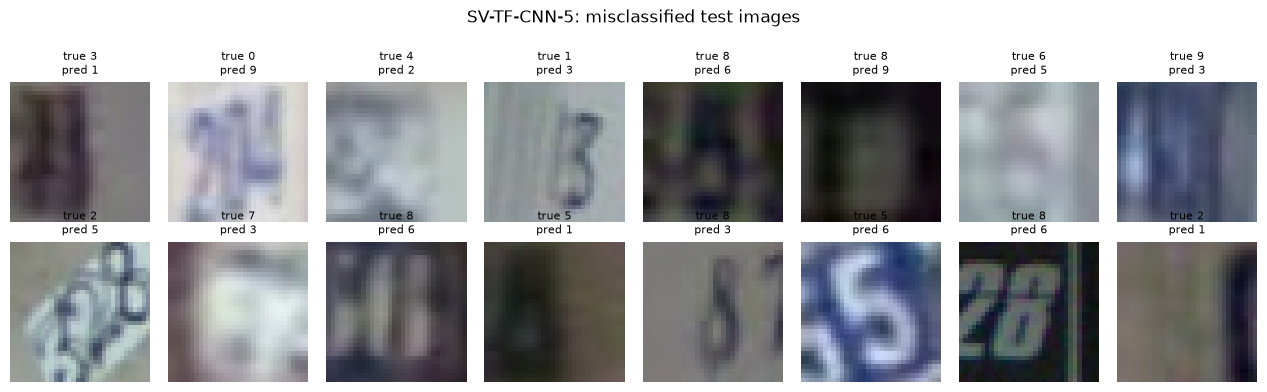

In [20]:
def show_misclassified(y_pred, run_id, n=16):
    wrong = np.where(y_pred != y_test)[0][:n]
    cols = 8
    rows = max(1, int(np.ceil(len(wrong) / cols)))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.9), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, i in zip(axes.ravel(), wrong):
        ax.imshow(X_test[i])
        ax.set_title(f"true {CLASS_LABELS[y_test[i]]}\npred {CLASS_LABELS[y_pred[i]]}", fontsize=8)
    fig.suptitle(f"{run_id}: misclassified test images", y=1.02)
    fig.tight_layout(); savefig(fig, f"{run_id}_misclassified"); plt.show()


show_misclassified(tf_preds["CNN-5"], f"{DATASET}-TF-CNN-5")

## 5. PyTorch

Same models, data and settings. What changes is how they are written:

| Step | Keras (section 4) | PyTorch |
|---|---|---|
| data | `tf.data` | `TensorDataset` + `DataLoader` |
| image layout | `(N, 32, 32, 3)` | `(N, 3, 32, 32)` |
| conv | `Conv2D(32, 3, padding="same")` | `Conv2d(3, 32, 3, padding=1)`: input channels written by hand |
| GAP | `GlobalAveragePooling2D()` | `AdaptiveAvgPool2d(1)` + `Flatten()` |
| initial weights | Glorot uniform (default) | set to Glorot (`xavier_uniform_`) to match |
| BatchNorm momentum | 0.9 (weight of the old value) | 0.1 (weight of the new value): same rule, `running = 0.9·running + 0.1·batch` |
| training | `compile` + `fit` | loop written by hand |
| early stopping | callback | counter inside the loop |

### 5.1 Data loader

In [21]:
from torch.utils.data import DataLoader, TensorDataset


def make_loader(x, y, training):
    ds = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))
    g = torch.Generator().manual_seed(SEED)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=training, generator=g if training else None)


train_loader = make_loader(X_train_pt, y_train, training=True)
val_loader = make_loader(X_val_pt, y_val, training=False)
test_loader = make_loader(X_test_pt, y_test, training=False)


def to_device(x):
    return x.to(DEVICE).float() / 255.0


xb, yb = next(iter(train_loader))
print("batch:", tuple(xb.shape), xb.dtype, "| labels:", tuple(yb.shape))

batch: (256, 3, 32, 32) torch.uint8 | labels: (256,)


### 5.2 Model class
Layers are created in `__init__`; `forward(x)` runs them in order. The cell also checks that each PyTorch model has exactly the Keras parameter count.

In [22]:
def init_like_keras(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)


class CNN(nn.Module):
    def __init__(self, model_name, in_channels, n_classes):
        super().__init__()
        blocks, c = [], in_channels
        for filters, pool in ARCH[model_name]:
            blocks += [nn.Conv2d(c, filters, kernel_size=3, padding=1),
                       nn.BatchNorm2d(filters, momentum=0.1, eps=1e-5),
                       nn.ReLU()]
            if pool:
                blocks.append(nn.MaxPool2d(2))
            c = filters
        self.features = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(DROPOUT),
            nn.Linear(c, HEAD_UNITS), nn.ReLU(),
            nn.Linear(HEAD_UNITS, n_classes),       # logits
        )
        self.apply(init_like_keras)

    def forward(self, x):
        return self.head(self.features(x))


def trainable_params_pt(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for m in MODELS:
    n_pt = trainable_params_pt(CNN(m, INPUT_CHANNELS, N_CLASSES))
    n_formula = expected_params(m, INPUT_CHANNELS, N_CLASSES).params.sum()
    assert n_pt == n_formula, (m, n_pt, n_formula)
    print(f"{m}: PyTorch {n_pt:,} = formula {n_formula:,} = Keras (match)")

CNN-3: PyTorch 129,290 = formula 129,290 = Keras (match)
CNN-5: PyTorch 175,658 = formula 175,658 = Keras (match)


### 5.3 Training loop

What `fit` did in Keras, one batch at a time:

| Line | Meaning |
|---|---|
| `optimizer.zero_grad()` | clear last batch's gradients (PyTorch adds them up otherwise) |
| `logits = model(x)` | forward pass: `(256, 3, 32, 32) → (256, 10)` |
| `loss = criterion(logits, y)` | cross-entropy, same formula as 4.5 |
| `loss.backward()` | backpropagation: gradient of the loss for every weight |
| `optimizer.step()` | Adam update |

- `model.train()`: dropout on, BatchNorm uses the batch's μ and σ.
- `model.eval()` + `torch.no_grad()`: dropout off, BatchNorm uses its running μ and σ, no gradients (validation, test).
- GPU work runs in the background, so the clock is read only after `synchronize()`.

In [23]:
def sync():
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    elif DEVICE.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss, correct, n, logits_all = 0.0, 0, 0, []
    for x, y in loader:
        x, y = to_device(x), y.to(DEVICE)
        logits = model(x)
        total_loss += criterion(logits, y).item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        n += len(y)
        logits_all.append(logits.cpu())
    return total_loss / n, correct / n, torch.cat(logits_all)


def train_pt(model):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, eps=1e-7)
    hist = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    epoch_times, best_loss, best_state, wait = [], float("inf"), None, 0

    for epoch in range(1, EPOCHS + 1):
        sync(); start = time.perf_counter()
        model.train()
        total_loss, correct, n = 0.0, 0, 0
        for x, y in train_loader:
            x, y = to_device(x), y.to(DEVICE)
            optimizer.zero_grad()              # 1. clear old gradients
            logits = model(x)                  # 2. forward pass
            loss = criterion(logits, y)        # 3. loss
            loss.backward()                    # 4. backpropagation
            optimizer.step()                   # 5. Adam update
            total_loss += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            n += len(y)
        val_loss, val_acc, _ = evaluate_loader(model, val_loader, criterion)
        sync(); epoch_times.append(time.perf_counter() - start)

        for k, v in zip(hist, (total_loss / n, correct / n, val_loss, val_acc)):
            hist[k].append(float(v))
        print(f"Epoch {epoch}/{EPOCHS} - {epoch_times[-1]:.1f}s - loss: {hist['loss'][-1]:.4f} - "
              f"accuracy: {hist['accuracy'][-1]:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        if val_loss < best_loss:               # early stopping, written by hand
            best_loss, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Epoch {epoch}: early stopping")
                break

    model.load_state_dict(best_state)
    best_epoch = int(np.argmin(hist["val_loss"])) + 1
    print(f"Restoring model weights from the end of the best epoch: {best_epoch}.")
    return hist, epoch_times, best_epoch


def evaluate_pt(model):
    criterion = nn.CrossEntropyLoss()
    evaluate_loader(model, [next(iter(test_loader))], criterion)       # warm-up
    sync()
    with Stopwatch() as t:
        _, _, logits = evaluate_loader(model, test_loader, criterion)
        sync()
    probs = torch.softmax(logits, dim=1).numpy()
    y_pred = probs.argmax(axis=1)
    return y_pred, probs, classification_metrics(y_test, y_pred), 1000 * t.seconds / len(y_test)


def run_pt(model_name):
    run_id = f"{DATASET}-PT-{model_name}"
    torch.manual_seed(SEED)
    model = CNN(model_name, INPUT_CHANNELS, N_CLASSES).to(DEVICE)
    params = trainable_params_pt(model)
    print(model)
    print(f"trainable parameters: {params:,}")
    hist, epoch_times, best_epoch = train_pt(model)
    y_pred, probs, metrics, ms_per_1k = evaluate_pt(model)
    record = make_record(run_id, "PT", model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k)
    save_result(record)
    torch.save(model.state_dict(), MODELS_DIR / f"{run_id}.pt")
    print(pd.Series(metrics).round(4).to_string())
    plot_history(record["history"], run_id)
    plot_confusion(y_test, y_pred, CLASS_LABELS, run_id)
    return model, y_pred, record

### 5.4 `SV-PT-CNN-3`

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.3, inplace

Epoch 1/20 - 48.4s - loss: 1.9402 - accuracy: 0.3156 - val_loss: 1.6137 - val_accuracy: 0.4452


Epoch 2/20 - 48.7s - loss: 1.3889 - accuracy: 0.5328 - val_loss: 1.1660 - val_accuracy: 0.6218


Epoch 3/20 - 50.5s - loss: 1.0485 - accuracy: 0.6590 - val_loss: 0.8719 - val_accuracy: 0.7309


Epoch 4/20 - 49.8s - loss: 0.8371 - accuracy: 0.7322 - val_loss: 0.7097 - val_accuracy: 0.7827


...

Epoch 15/20 - 50.5s - loss: 0.3203 - accuracy: 0.9034 - val_loss: 0.3115 - val_accuracy: 0.9094


Epoch 16/20 - 48.7s - loss: 0.3084 - accuracy: 0.9058 - val_loss: 0.3263 - val_accuracy: 0.9028


Epoch 17/20 - 49.7s - loss: 0.2959 - accuracy: 0.9105 - val_loss: 0.3311 - val_accuracy: 0.9036


Epoch 18/20 - 48.9s - loss: 0.2849 - accuracy: 0.9138 - val_loss: 0.3375 - val_accuracy: 0.8983
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 15.


accuracy           0.9106
precision_macro    0.9090
recall_macro       0.9014
f1_macro           0.9046


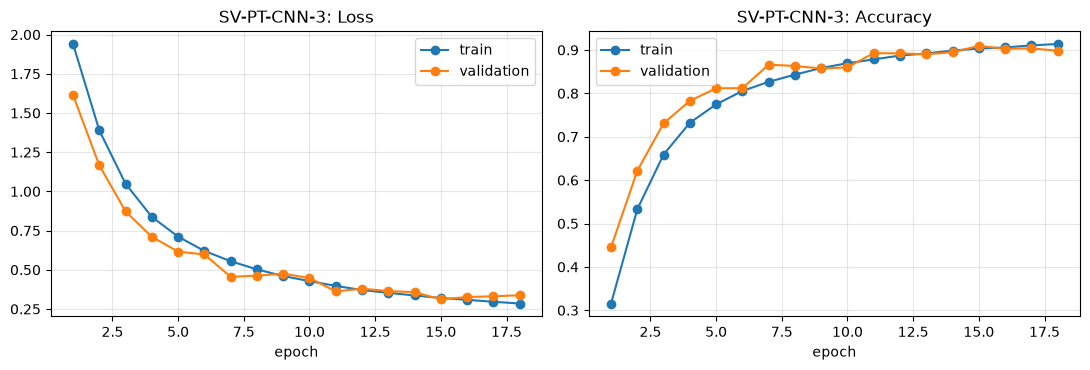

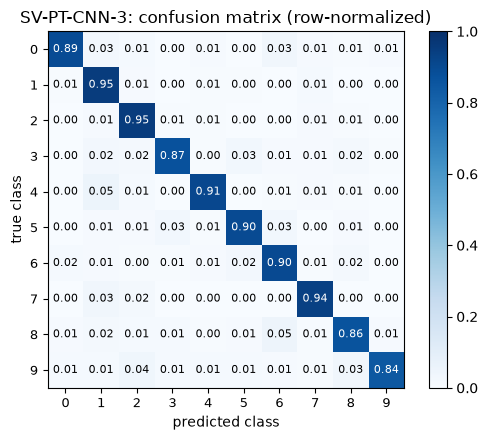

In [24]:
pt_models, pt_preds = {}, {}
pt_models["CNN-3"], pt_preds["CNN-3"], _ = run_pt("CNN-3")

### 5.5 `SV-PT-CNN-5`

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_s

Epoch 1/20 - 101.3s - loss: 1.7077 - accuracy: 0.4037 - val_loss: 1.0336 - val_accuracy: 0.6708


Epoch 2/20 - 98.6s - loss: 0.6584 - accuracy: 0.7900 - val_loss: 0.5830 - val_accuracy: 0.8156


Epoch 3/20 - 98.8s - loss: 0.4367 - accuracy: 0.8635 - val_loss: 0.4378 - val_accuracy: 0.8662


Epoch 4/20 - 98.7s - loss: 0.3563 - accuracy: 0.8909 - val_loss: 0.3348 - val_accuracy: 0.9016


...

Epoch 10/20 - 98.8s - loss: 0.2141 - accuracy: 0.9374 - val_loss: 0.2542 - val_accuracy: 0.9284


Epoch 11/20 - 98.6s - loss: 0.1993 - accuracy: 0.9416 - val_loss: 0.2544 - val_accuracy: 0.9278


Epoch 12/20 - 99.3s - loss: 0.1903 - accuracy: 0.9453 - val_loss: 0.3301 - val_accuracy: 0.9034


Epoch 13/20 - 99.2s - loss: 0.1828 - accuracy: 0.9470 - val_loss: 0.2893 - val_accuracy: 0.9199
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 10.


accuracy           0.9294
precision_macro    0.9273
recall_macro       0.9248
f1_macro           0.9250


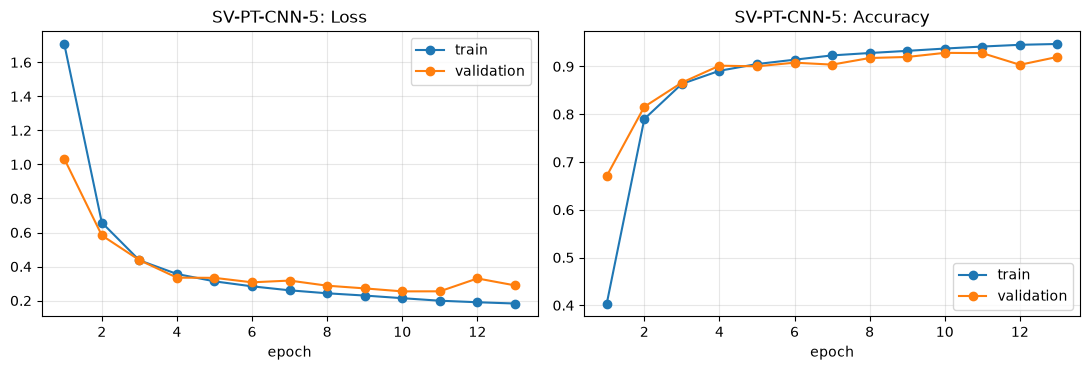

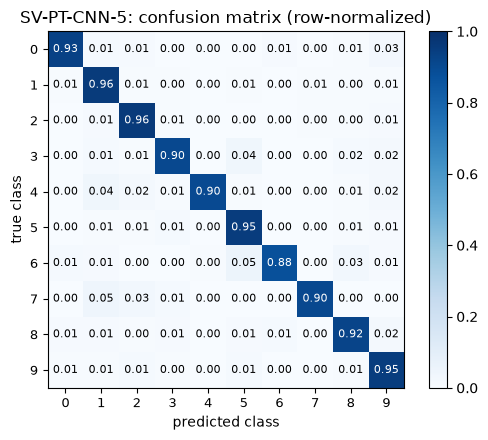

In [25]:
pt_models["CNN-5"], pt_preds["CNN-5"], _ = run_pt("CNN-5")

### 5.6 What the first layer learned

PyTorch stores filters as `(F, C_in, K, K) = (32, 3, 3, 3)`. Feature maps are captured with a **forward hook**:
a small function attached to the first ReLU that saves its output while the image passes through.

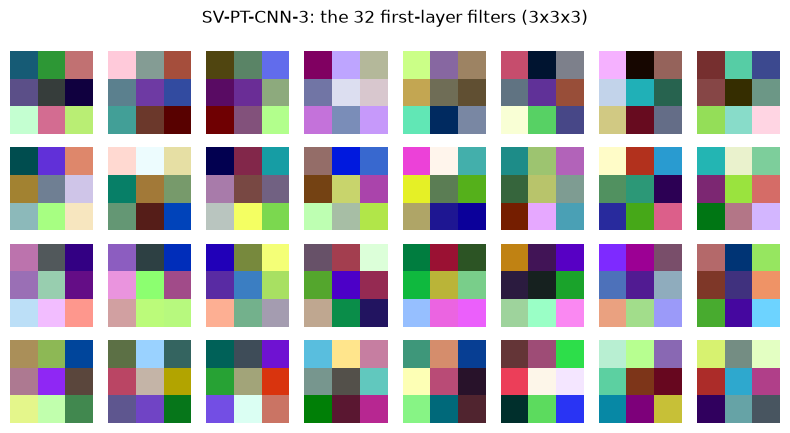

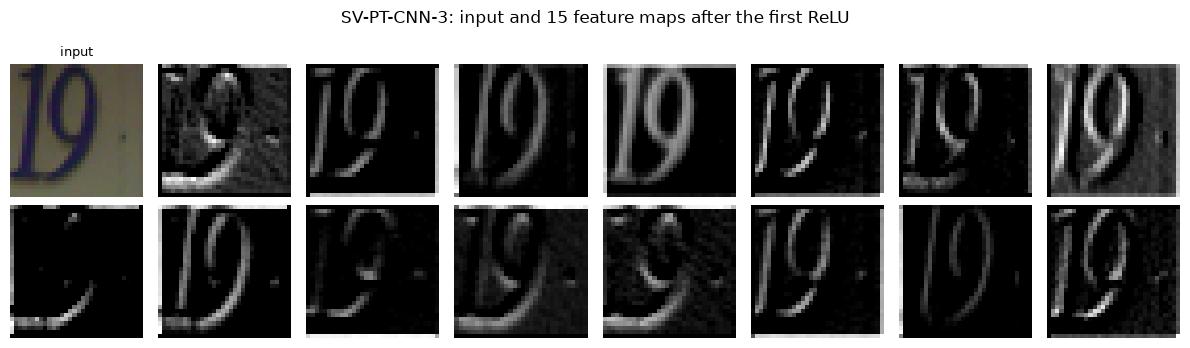

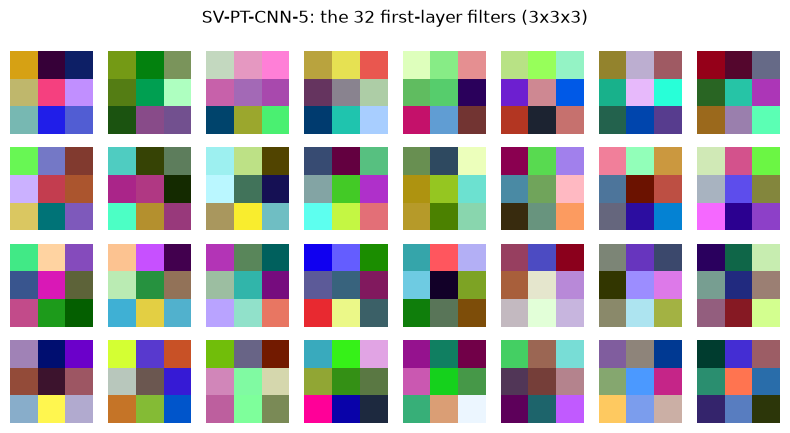

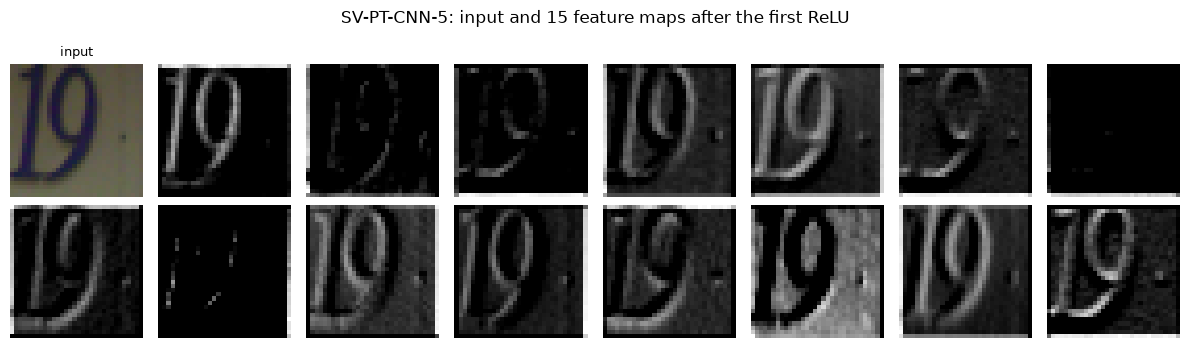

In [26]:
def pt_filters(m):
    return pt_models[m].features[0].weight.detach().cpu().numpy().transpose(0, 2, 3, 1)   # (F, K, K, C_in)


def pt_maps(m):
    model, captured = pt_models[m].eval(), {}
    relu = next(l for l in model.features if isinstance(l, nn.ReLU))
    handle = relu.register_forward_hook(lambda mod, inp, out: captured.update(out=out))
    with torch.no_grad():
        model(torch.from_numpy(np.transpose(sample, (0, 3, 1, 2))).to(DEVICE))
    handle.remove()
    return captured["out"][0].cpu().numpy()                                               # (F, H, W)


for m in MODELS:
    show_filters(pt_filters(m), f"{DATASET}-PT-{m}")
    show_feature_maps(pt_maps(m), f"{DATASET}-PT-{m}")

### 5.7 Errors

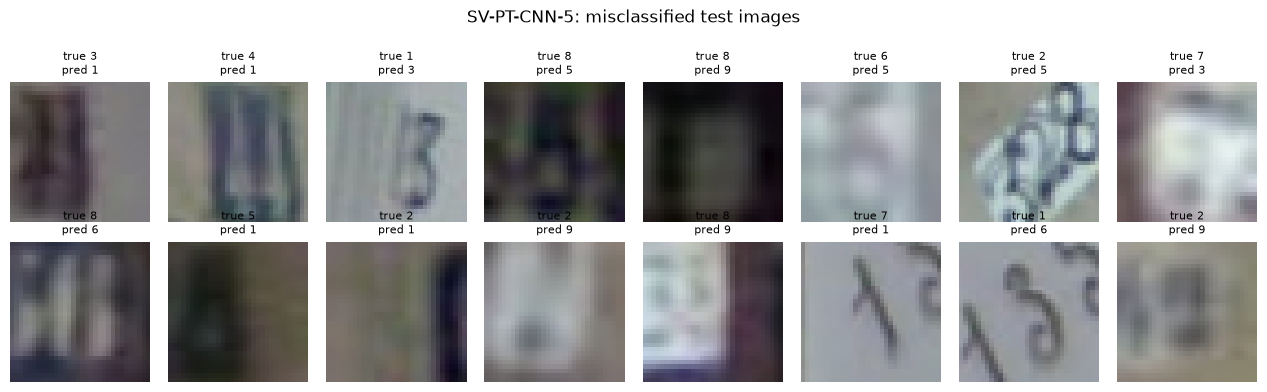

In [27]:
show_misclassified(pt_preds["CNN-5"], f"{DATASET}-PT-CNN-5")

## 6. Comparison

The table is read from the four `results/<run_id>.json` files (the same files the report uses).
`time_per_epoch_s` = median of epochs 2+; `train_time_s` = all epochs; `inference_ms_per_1k` = time to predict 1,000 images.

In [28]:
records = load_results(RUN_IDS)
comparison = results_table(records)
comparison.to_csv(RESULTS_DIR / f"{DATASET}_comparison.csv")
comparison.round(4)

,framework,model,params,epochs,time_per_epoch_s,train_time_s,inference_ms_per_1k,accuracy,precision_macro,recall_macro,f1_macro
run_id,,,,,,,,,,,
SV-TF-CNN-3,TF,CNN-3,129290,20,44.9506,898.0445,0.0988,0.9117,0.9068,0.9104,0.9072
SV-TF-CNN-5,TF,CNN-5,175658,10,86.5364,868.2495,0.2168,0.9306,0.9286,0.9248,0.9265
SV-PT-CNN-3,PT,CNN-3,129290,18,48.8836,883.6183,0.2702,0.9106,0.9090,0.9014,0.9046
SV-PT-CNN-5,PT,CNN-5,175658,13,98.7407,1287.4240,0.4927,0.9294,0.9273,0.9248,0.9250


Charts (two per figure) and the two differences: **CNN-5 − CNN-3** in each framework, and **PT − TF** for each model.

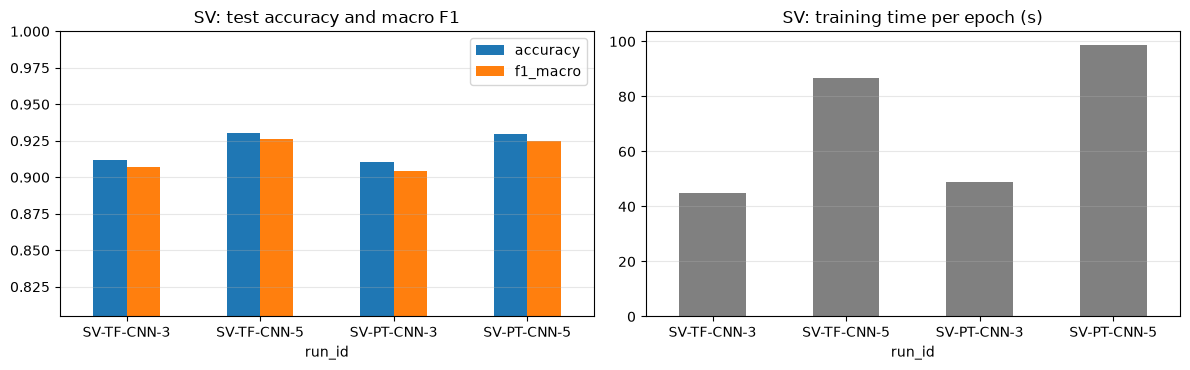

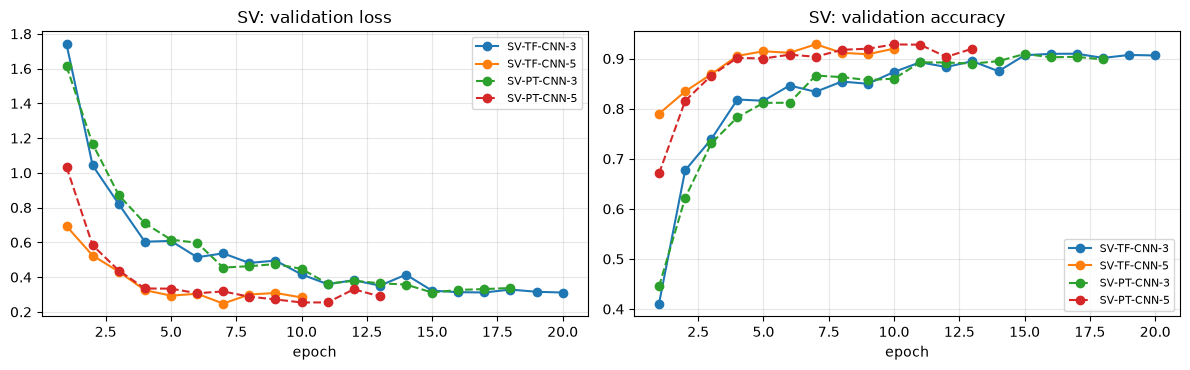

CNN-5 minus CNN-3 (per framework):


,accuracy,f1_macro,params,time_per_epoch_s,epochs
TF,0.0189,0.0194,46368.0,41.5858,-10.0
PT,0.0188,0.0204,46368.0,49.8572,-5.0


PT minus TF (per model):


,accuracy,f1_macro,params,time_per_epoch_s,epochs
CNN-3,-0.0011,-0.0025,0.0,3.9330,-2.0
CNN-5,-0.0012,-0.0015,0.0,12.2043,3.0


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
comparison[["accuracy", "f1_macro"]].plot.bar(ax=axes[0], rot=0)
axes[0].set_ylim(max(0, comparison[["accuracy", "f1_macro"]].min().min() - 0.1), 1)
axes[0].set_title(f"{DATASET}: test accuracy and macro F1"); axes[0].grid(axis="y", alpha=0.3)
comparison["time_per_epoch_s"].plot.bar(ax=axes[1], rot=0, color="gray")
axes[1].set_title(f"{DATASET}: training time per epoch (s)"); axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout(); savefig(fig, f"{DATASET}_comparison_bars"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for r in records:
    style = "-" if r["framework"] == "TF" else "--"
    ep = np.arange(1, len(r["history"]["val_loss"]) + 1)
    axes[0].plot(ep, r["history"]["val_loss"], style, marker="o", label=r["run_id"])
    axes[1].plot(ep, r["history"]["val_accuracy"], style, marker="o", label=r["run_id"])
axes[0].set_title(f"{DATASET}: validation loss"); axes[1].set_title(f"{DATASET}: validation accuracy")
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); savefig(fig, f"{DATASET}_comparison_curves"); plt.show()

cols = ["accuracy", "f1_macro", "params", "time_per_epoch_s", "epochs"]
by = comparison.set_index(["framework", "model"])[cols]
print("CNN-5 minus CNN-3 (per framework):")
display(pd.DataFrame({fw: by.loc[(fw, "CNN-5")] - by.loc[(fw, "CNN-3")] for fw in FRAMEWORKS}).T.round(4))
print("PT minus TF (per model):")
display(pd.DataFrame({m: by.loc[("PT", m)] - by.loc[("TF", m)] for m in MODELS}).T.round(4))

**Discussion**

| | CNN-3 | CNN-5 | CNN-5 − CNN-3 |
|---|---|---|---|
| TF macro F1 | 0.9072 | 0.9265 | +0.0194 |
| PT macro F1 | 0.9046 | 0.9250 | +0.0204 |
| TF s/epoch | 45.0 | 86.5 | ×1.92 |
| PT s/epoch | 48.9 | 98.7 | ×2.02 |

- **Depth helps.** CNN-5 gains about 2 points of accuracy and macro F1 in both frameworks. Its receptive field is 28×28 instead of 22×22, so one unit sees almost the whole digit and can tell look-alikes apart.
- **Cost.** Each CNN-5 epoch takes about 2× longer, but CNN-5 reached its best validation loss sooner (10 and 13 epochs vs 20 and 18), so total training time is 0.97× (TF) and 1.46× (PT) that of CNN-3.
- **Frameworks agree.** TF and PT differ by 0.001 accuracy for both depths. Keras was 9–14% faster per epoch on this CPU run.
- **Errors.** The most frequent confusions are 7 → 1 (6% of the 7s), 5 → 3 (4%) and 4 → 1 (3%): digits that share a vertical stroke. The misclassified grid shows blurred, low-contrast images and images where a neighbouring digit dominates.

## 7. Conclusion

1. CNN-5 is the better model on SVHN: macro F1 0.9265 (TF) / 0.9250 (PT) vs 0.9072 / 0.9046 for CNN-3.
2. The extra depth doubles the time per epoch but converges in fewer epochs, so the real cost is small.
3. Keras and PyTorch give practically the same result (≤ 0.003 macro F1 apart) with identical architectures and settings.
4. Remaining errors come from the data itself (blur, neighbouring digits, 1/7 and 3/5 look-alikes), not from one framework.